In [50]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

import datetime

In [51]:
df = pd.read_csv("C:\\Users\\abhik\\Downloads\\ds_projects\\credit-card-fraud-detection-project\\data\\raw\\fraudTest.csv")

In [52]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,25-07-1987,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,06-07-1955,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [53]:
df.shape

(553976, 22)

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 553976 entries, 0 to 553975
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  553976 non-null  object 
 1   cc_num                 553976 non-null  float64
 2   merchant               553976 non-null  object 
 3   category               553976 non-null  object 
 4   amt                    553976 non-null  float64
 5   first                  553976 non-null  object 
 6   last                   553976 non-null  object 
 7   gender                 553976 non-null  object 
 8   street                 553976 non-null  object 
 9   city                   553976 non-null  object 
 10  state                  553976 non-null  object 
 11  zip                    553976 non-null  int64  
 12  lat                    553976 non-null  float64
 13  long                   553976 non-null  float64
 14  city_pop               553976 non-nu

In [55]:
df.nunique()

trans_date_trans_time    226619
cc_num                      891
merchant                    693
category                     14
amt                       36148
first                       339
last                        467
gender                        2
street                      911
city                        839
state                        50
zip                         900
lat                         898
long                        898
city_pop                    825
job                         476
dob                         897
trans_num                553976
unix_time                543081
merch_lat                544800
merch_long               550052
is_fraud                      2
dtype: int64

In [56]:
df.isnull().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [57]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.539760e+05,553976.000000,553976.000000,553976.000000,553976.000000,5.539760e+05,5.539760e+05,553976.000000,553976.000000,553976.000000
mean,4.182843e+17,67.932167,48844.825211,38.541985,-90.231056,8.830109e+04,1.380678e+09,38.541508,-90.231032,0.000726
std,1.310447e+18,153.237978,26855.393978,5.061831,13.722332,3.005941e+05,5.204989e+06,5.096347,13.733615,0.026928
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800430e+14,9.607500,26292.000000,34.668900,-96.798000,7.410000e+02,1.376022e+09,34.755032,-96.905665,0.000000
50%,3.521420e+15,47.170000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380759e+09,39.375085,-87.443376,0.000000
75%,4.642260e+15,82.690000,72042.000000,41.894800,-80.175200,1.968500e+04,1.385870e+09,41.954249,-80.265129,0.000000
max,4.992350e+18,22768.110000,99783.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [58]:
df['is_fraud'].value_counts()

is_fraud
0    553574
1       402
Name: count, dtype: int64

In [59]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.999274
1    0.000726
Name: proportion, dtype: float64

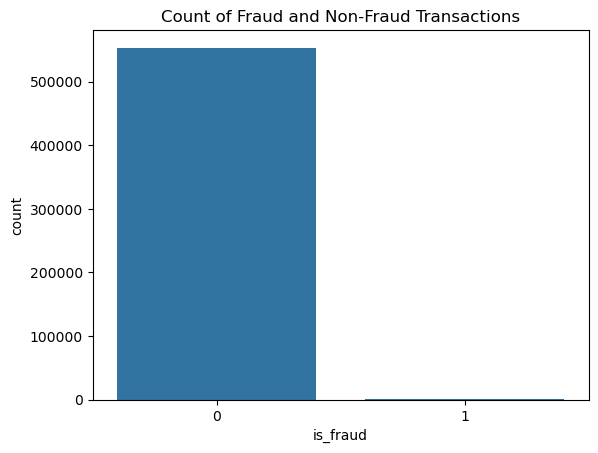

In [60]:
#Plotting the count of fraud and non-fraud transactions
sns.countplot(x='is_fraud', data=df)
plt.title('Count of Fraud and Non-Fraud Transactions')
plt.show()

In [61]:
drop_cols = [
    'first', 'last', 'street', 'trans_num', 'unix_time'
]

df = df.drop(columns=drop_cols)

In [62]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud
0,21-06-2020 12:14,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,33.986391,-81.200714,0
1,21-06-2020 12:14,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,39.450498,-109.960431,0
2,21-06-2020 12:14,3.598220e+15,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,F,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",21-10-1970,40.495810,-74.196111,0
3,21-06-2020 12:15,3.591920e+15,fraud_Haley Group,misc_pos,60.05,M,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,25-07-1987,28.812398,-80.883061,0
4,21-06-2020 12:15,3.526830e+15,fraud_Johnston-Casper,travel,3.19,M,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,06-07-1955,44.959148,-85.884734,0


In [63]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [64]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day'] = df['trans_date_trans_time'].dt.day
df['month'] = df['trans_date_trans_time'].dt.month
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek

In [65]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week
0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,19-03-1968,33.986391,-81.200714,0,12,21,6,6
1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",17-01-1990,39.450498,-109.960431,0,12,21,6,6


In [66]:
## Age from DOB

df['dob'] = pd.to_datetime(df['dob'])
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

In [67]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age
0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52
1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,21,6,6,30


In [68]:
## Distance between transaction location and merchant location
import numpy as np

def haversine_vectorized(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

# Apply vectorized
df['distance'] = haversine_vectorized(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)

In [69]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age,distance
0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52,24.561462
1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,21,6,6,30,104.925092


#### Finding Velocity

In [70]:
# total_seconds() handles differences longer than one day
df['time_diff_total_seconds'] = df.groupby('cc_num')['trans_date_trans_time'].diff().dt.total_seconds()

# To get minutes or hours
df['time_diff_minutes'] = df['time_diff_total_seconds'] / 60
df['time_diff_hours'] = df['time_diff_total_seconds'] / 3600

In [71]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age,distance,time_diff_total_seconds,time_diff_minutes,time_diff_hours
0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52,24.561462,NaN,NaN,NaN
1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,21,6,6,30,104.925092,NaN,NaN,NaN


In [72]:
# Calculate velocity (km/h)
# We use .replace(0, np.nan) to avoid "division by zero" errors for simultaneous transactions
df['velocity_kmh'] = df['distance'] / df['time_diff_hours'].replace(0, np.nan)

In [73]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,category,amt,gender,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age,distance,time_diff_total_seconds,time_diff_minutes,time_diff_hours,velocity_kmh
0,2020-06-21 12:14:00,2.291160e+15,fraud_Kirlin and Sons,personal_care,2.86,M,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52,24.561462,NaN,NaN,NaN,NaN
1,2020-06-21 12:14:00,3.573030e+15,fraud_Sporer-Keebler,personal_care,29.84,F,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,39.450498,-109.960431,0,12,21,6,6,30,104.925092,NaN,NaN,NaN,NaN


In [74]:
# One hot encoding for low cardinality categorical variables using pandas get_dummies
low_card_cols = ['category', 'gender']

In [75]:
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True)

In [76]:
high_card_cols = ['merchant', 'city', 'state', 'job']

In [77]:
## Frequency encoding for high cardinality columns
for col in high_card_cols:
    freq = df[col].value_counts(normalize=True)
    df[col] = df[col].map(freq)

In [78]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,amt,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age,distance,time_diff_total_seconds,time_diff_minutes,time_diff_hours,velocity_kmh,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,2020-06-21 12:14:00,2.291160e+15,0.001323,2.86,0.001155,0.022588,29209,33.9659,-80.9355,333497,0.004386,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52,24.561462,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,True,False,False,False,True
1,2020-06-21 12:14:00,3.573030e+15,0.001415,29.84,0.001511,0.008408,84002,40.3207,-110.4360,302,0.004576,1990-01-17,39.450498,-109.960431,0,12,21,6,6,30,104.925092,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,True,False,False,False,False


In [79]:
df.columns

Index(['trans_date_trans_time', 'cc_num', 'merchant', 'amt', 'city', 'state',
       'zip', 'lat', 'long', 'city_pop', 'job', 'dob', 'merch_lat',
       'merch_long', 'is_fraud', 'hour', 'day', 'month', 'day_of_week', 'age',
       'distance', 'time_diff_total_seconds', 'time_diff_minutes',
       'time_diff_hours', 'velocity_kmh', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'gender_M'],
      dtype='object')

In [80]:
binary_cols = [
    'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'gender_M'
]

In [81]:
df[binary_cols] = df[binary_cols].astype(int)

In [82]:
df.head(2)

,trans_date_trans_time,cc_num,merchant,amt,city,state,zip,lat,long,city_pop,job,dob,merch_lat,merch_long,is_fraud,hour,day,month,day_of_week,age,distance,time_diff_total_seconds,time_diff_minutes,time_diff_hours,velocity_kmh,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,2020-06-21 12:14:00,2.291160e+15,0.001323,2.86,0.001155,0.022588,29209,33.9659,-80.9355,333497,0.004386,1968-03-19,33.986391,-81.200714,0,12,21,6,6,52,24.561462,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1,0,0,0,1
1,2020-06-21 12:14:00,3.573030e+15,0.001415,29.84,0.001511,0.008408,84002,40.3207,-110.4360,302,0.004576,1990-01-17,39.450498,-109.960431,0,12,21,6,6,30,104.925092,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [83]:
## Time Based Train-Test-Split
## Sort by transaction time
fraud_df = df[df['is_fraud'] == 1]
non_fraud_df = df[df['is_fraud'] == 0]

# Sort each separately
fraud_df = fraud_df.sort_values('trans_date_trans_time')
non_fraud_df = non_fraud_df.sort_values('trans_date_trans_time')

# Split
fraud_split = int(len(fraud_df) * 0.8)
non_fraud_split = int(len(non_fraud_df) * 0.8)

train = pd.concat([
    fraud_df.iloc[:fraud_split],
    non_fraud_df.iloc[:non_fraud_split]
])

test = pd.concat([
    fraud_df.iloc[fraud_split:],
    non_fraud_df.iloc[non_fraud_split:]
])

# Shuffle within sets (important)
train = train.sample(frac=1, random_state=42)
test = test.sample(frac=1, random_state=42)

In [84]:
# Separate features and target variable
X_train = train.drop(columns=['is_fraud', 'trans_date_trans_time', 'dob'])
y_train = train['is_fraud']

X_test = test.drop(columns=['is_fraud', 'trans_date_trans_time', 'dob'])
y_test = test['is_fraud']

In [85]:
# Handle class imbalance using scale_pos_weight for XGBoost
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

In [86]:
scoring = "average_precision"   # AUPRC

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import TimeSeriesSplit
import xgboost as xgb

param_dist = {
    "n_estimators": [200, 400, 600, 800],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 1, 5],
    "min_child_weight": [1, 5, 10]
}

model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="aucpr",
    random_state=42
)


tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=10,
    scoring="average_precision",
    cv=tscv,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 1, ...], 'learning_rate': [0.01, 0.03, ...], 'max_depth': [4, 6, ...], ...}"
,n_iter,10
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [88]:
'''model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)

model.fit(X_train, y_train)'''

"model = XGBClassifier(\n    n_estimators=200,\n    max_depth=6,\n    learning_rate=0.1,\n    scale_pos_weight=scale_pos_weight,\n    eval_metric='aucpr',\n    random_state=42\n)\n\nmodel.fit(X_train, y_train)"

In [89]:
#Get best model
best_model = random_search.best_estimator_

print("Best Params:", random_search.best_params_)

Best Params: {'subsample': 1.0, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}


In [90]:
#Evaluate Best Model
y_prob = best_model.predict_proba(X_test)[:, 1]

In [91]:
#Combine with Threshold Optimization
import numpy as np

thresholds = np.linspace(0, 1, 100)

best_threshold = 0
best_cost = float('inf')

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    cost = fn * 10000 + fp * 200
    
    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print("Best Threshold:", best_threshold)
import numpy as np

thresholds = np.linspace(0, 1, 100)

best_threshold = 0
best_cost = float('inf')

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    cost = fn * 10000 + fp * 200
    
    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.010101010101010102
Best Threshold: 0.010101010101010102


In [ ]:
'''y_pred = (y_prob >= 0.01).astype(int)'''

In [105]:
import numpy as np
from sklearn.metrics import confusion_matrix

thresholds = np.linspace(0, 0.2, 100)

best_threshold = 0
best_cost = float('inf')

COST_FN = 10000
COST_FP = 200

results = []

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    cost = fn * COST_FN + fp * COST_FP
    
    results.append((t, cost, fp, fn))
    
    if cost < best_cost:
        best_cost = cost
        best_threshold = t

print("Best Threshold:", best_threshold)
print("Minimum Cost:", best_cost)

Best Threshold: 0.00202020202020202
Minimum Cost: 240600


In [106]:
best_t = 0.00202020202020202

y_pred = (y_prob >= best_t).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Precision: 0.95
Recall: 0.7037037037037037
F1: 0.8085106382978723
Confusion Matrix:
 [[110712      3]
 [    24     57]]


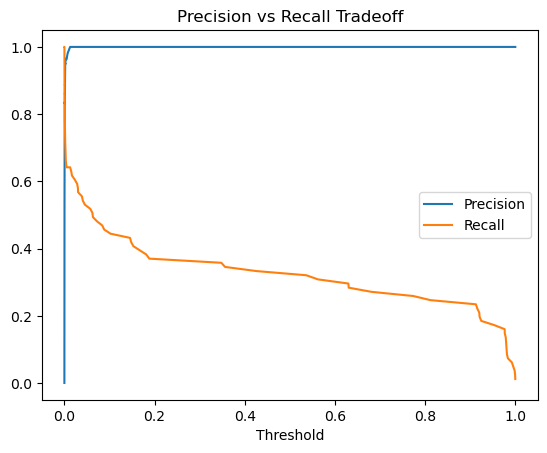

In [97]:
#Plot Precision-Recall Curve
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

import matplotlib.pyplot as plt

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision vs Recall Tradeoff")
plt.show()

In [ ]:
#saving the model and the threshold
import joblib
joblib.dump(best_model, "model.pkl")
joblib.dump(best_threshold, "best_threshold.pkl")